In [35]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size="5" color="red">RNN</font>
# 1. 문맥을 이용하여 모델 만들기

In [36]:
text = """경마장에 있는 말이 뛰고 있다 
그의 말이 법이다
가는 말이 고아야 오는 말이 곱다"""
text1 = "장마철이 오고 있다"

In [37]:
from keras_preprocessing.text import Tokenizer

t = Tokenizer()

# Correct method to fit the tokenizer on the text
t.fit_on_texts([text, text1])

# Convert the texts to sequences
encoded = t.texts_to_sequences([text, text1])

# Print the encoded sequences
print(encoded)
print(t.word_index)

[[3, 4, 1, 5, 2, 6, 1, 7, 8, 1, 9, 10, 1, 11], [12, 13, 2]]
{'말이': 1, '있다': 2, '경마장에': 3, '있는': 4, '뛰고': 5, '그의': 6, '법이다': 7, '가는': 8, '고아야': 9, '오는': 10, '곱다': 11, '장마철이': 12, '오고': 13}


In [38]:
from keras_preprocessing.text import Tokenizer

t = Tokenizer()

# Correct method to fit the tokenizer on the text
t.fit_on_texts([text])

# Convert the texts to sequences
encoded = t.texts_to_sequences([text])

# Print the encoded sequences
print(encoded)
print(t.word_index)

[[2, 3, 1, 4, 5, 6, 1, 7, 8, 1, 9, 10, 1, 11]]
{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고아야': 9, '오는': 10, '곱다': 11}


In [39]:
# 문자열 리스트를 인덱스 시퀀스로 변환
print(t.texts_to_sequences(['경마장에 말이 있다']))
print(t.texts_to_sequences(['가는 말이 곱다'])[0])

[[2, 1, 5]]
[8, 1, 11]


In [40]:
text = """경마장에 있는 말이 뛰고 있다 
그의 말이 법이다
가는 말이 고아야 오는말이 곱다"""

In [41]:
for key, value in t.word_index.items():
    print(key, value)

말이 1
경마장에 2
있는 3
뛰고 4
있다 5
그의 6
법이다 7
가는 8
고아야 9
오는 10
곱다 11


In [42]:
# 학습을 시키기 위해 ['경마장에 있는','경마장에 있는 말이', ...]
sequences = []
for line in text.split('\n'):
    print('원문장 :', line)
    encoded = t.texts_to_sequences([line])[0]
    print('encoded된 문장 :', encoded)
    for i in range(0, len(encoded)-1): # i:시작index
        for j in range(i+2, len(encoded)+1): # j:끝나는 index바로 뒤
            sequences.append(encoded[i:j])
# print(sequences)
print('sequences와 해석 출력')
for sequence in sequences:
    for word_seq in sequence:
        for word, id in t.word_index.items():
            if word_seq==id:
                print("{}:{}".format(word_seq, word), end=' ')
                break
    print()

원문장 : 경마장에 있는 말이 뛰고 있다 
encoded된 문장 : [2, 3, 1, 4, 5]
원문장 : 그의 말이 법이다
encoded된 문장 : [6, 1, 7]
원문장 : 가는 말이 고아야 오는말이 곱다
encoded된 문장 : [8, 1, 9, 11]
sequences와 해석 출력
2:경마장에 3:있는 
2:경마장에 3:있는 1:말이 
2:경마장에 3:있는 1:말이 4:뛰고 
2:경마장에 3:있는 1:말이 4:뛰고 5:있다 
3:있는 1:말이 
3:있는 1:말이 4:뛰고 
3:있는 1:말이 4:뛰고 5:있다 
1:말이 4:뛰고 
1:말이 4:뛰고 5:있다 
4:뛰고 5:있다 
6:그의 1:말이 
6:그의 1:말이 7:법이다 
1:말이 7:법이다 
8:가는 1:말이 
8:가는 1:말이 9:고아야 
8:가는 1:말이 9:고아야 11:곱다 
1:말이 9:고아야 
1:말이 9:고아야 11:곱다 
9:고아야 11:곱다 


In [43]:
print([len(sequence) for sequence in sequences])
my_len = max(len(sequence) for sequence in sequences)
my_len

[2, 3, 4, 5, 2, 3, 4, 2, 3, 2, 2, 3, 2, 2, 3, 4, 2, 3, 2]


5

In [44]:

# sequences를 훈련 가능하도록 모두 6개로 조정
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(sequences=sequences,
                                maxlen=my_len,
                                padding='pre')
padded_sequences.shape, type(padded_sequences)

((19, 5), numpy.ndarray)

In [45]:
# 독립변수(x)와 타겟변수(y)로 분리
x = padded_sequences[:, :-1]
y = padded_sequences[:, -1]
y

array([ 3,  1,  4,  5,  1,  4,  5,  4,  5,  5,  1,  7,  7,  1,  9, 11,  9,
       11, 11])

In [46]:
# 컴퓨터가 엠베딩 작업할 때 필요한 입력 bit 수 (단어수+1)
input_dim = len(t.word_index) +1
input_dim

12

In [47]:
# y의 원핫인코딩

In [48]:
from tensorflow.keras.utils import to_categorical
y = to_categorical(y, input_dim)
x.shape, y.shape

((19, 4), (19, 12))

In [49]:
# 모델 생성하기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding  # xi 의 원핫인코딩한 희소행렬 변환
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

model = Sequential()
model.add(Embedding(input_dim=input_dim,      # 12개로 원핫 인코딩
                   output_dim=10,             # 임베딩 풀력의 갯수
                   input_length=x.shape[1]))  # 입력의 X 의 수
model.add(SimpleRNN(units=32))
model.add(Dense(12, activation='softmax'))
print(model.summary())
# 모델 학습과정 설정
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
# 모델학습 시키기
hist = model.fit(x, y, epochs=300, verbose=2)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 4, 10)             120       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 32)                1376      
                                                                 
 dense_1 (Dense)             (None, 12)                396       
                                                                 
Total params: 1,892
Trainable params: 1,892
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/300
1/1 - 1s - loss: 2.4846 - accuracy: 0.1053 - 788ms/epoch - 788ms/step
Epoch 2/300
1/1 - 0s - loss: 2.4735 - accuracy: 0.1053 - 5ms/epoch - 5ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4624 - accuracy: 0.1579 - 4ms/epoch - 4ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4512 - accuracy: 0.1579 - 4ms/epoch - 4ms/

Epoch 95/300
1/1 - 0s - loss: 1.2164 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 96/300
1/1 - 0s - loss: 1.2039 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 97/300
1/1 - 0s - loss: 1.1915 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 98/300
1/1 - 0s - loss: 1.1791 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 99/300
1/1 - 0s - loss: 1.1668 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 100/300
1/1 - 0s - loss: 1.1545 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 101/300
1/1 - 0s - loss: 1.1424 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 102/300
1/1 - 0s - loss: 1.1303 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 103/300
1/1 - 0s - loss: 1.1182 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 104/300
1/1 - 0s - loss: 1.1063 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 105/300
1/1 - 0s - loss: 1.0944 - accuracy: 0.5789 - 4ms/epoch - 4ms/step
Epoch 106/300
1/1 - 0s - loss: 1.0827 - accuracy: 0.6316 - 4ms/epoch - 4ms/step
Epoch 107/300
1/1 - 0s - loss: 1.0710 - accur

Epoch 198/300
1/1 - 0s - loss: 0.4263 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 199/300
1/1 - 0s - loss: 0.4228 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 200/300
1/1 - 0s - loss: 0.4194 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 201/300
1/1 - 0s - loss: 0.4161 - accuracy: 0.8947 - 5ms/epoch - 5ms/step
Epoch 202/300
1/1 - 0s - loss: 0.4128 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 203/300
1/1 - 0s - loss: 0.4095 - accuracy: 0.8947 - 6ms/epoch - 6ms/step
Epoch 204/300
1/1 - 0s - loss: 0.4064 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 205/300
1/1 - 0s - loss: 0.4032 - accuracy: 0.8947 - 5ms/epoch - 5ms/step
Epoch 206/300
1/1 - 0s - loss: 0.4001 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 207/300
1/1 - 0s - loss: 0.3971 - accuracy: 0.8947 - 5ms/epoch - 5ms/step
Epoch 208/300
1/1 - 0s - loss: 0.3941 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 209/300
1/1 - 0s - loss: 0.3911 - accuracy: 0.8947 - 4ms/epoch - 4ms/step
Epoch 210/300
1/1 - 0s - loss: 0.3882 - 

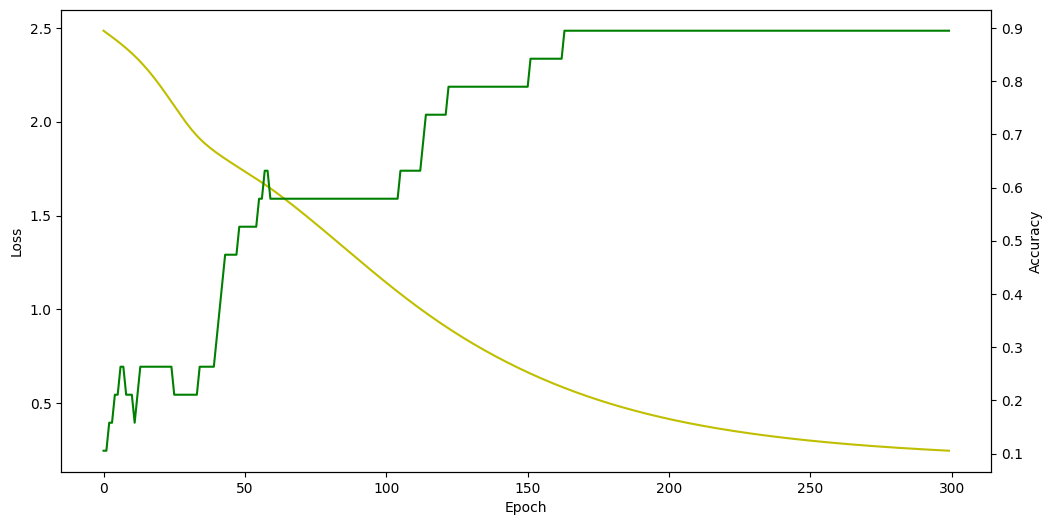

In [50]:
import matplotlib.pyplot as plt

# 하나의 Figure + 2개의 y축 (왼쪽: 손실, 오른쪽: 정확도)
fig, loss_ax = plt.subplots(figsize=(12, 6))

# 왼쪽 y축: Loss
loss_ax.plot(hist.history['loss'], 'y', label='Train Loss')

loss_ax.set_xlabel('Epoch')
loss_ax.set_ylabel('Loss')


# 오른쪽 y축: Accuracy
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='Train Acc')

acc_ax.set_ylabel('Accuracy')


plt.show()


In [58]:
input_word = input('입력단어:')
# 입력 텍스트를 시퀀스로 변환
encoded = t.texts_to_sequences([input_word])[0]

# 시퀀스를 모델에 맞게 패딩 처리
input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')

# 예측 결과 (argmax()를 사용하여 가장 높은 확률의 인덱스를 반환)
result = model.predict(input_data).argmax()

# 결과 인덱스를 단어로 변환
word = t.index_word[result]

# 예측된 단어 출력

print(word)


입력단어:가는 말이
1/1 [==============================] - 0s 20ms/step
고아야


In [56]:
t.texts_to_sequences(['없는 단어'])

[[]]

In [79]:
# "경마장에" 이후에 올 단어 3개 예측 -> 경마장에 있는 말이 뛰고
def sentence_generation(current_word, n):
    # print('입력된 단어 :', current_word)
    for i in range(1, n+1):
        encoded = t.texts_to_sequences([current_word])[0]
        input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')
        result = model.predict(input_data, verbose=0).argmax()
        word = t.index_word[result]
        current_word = current_word + ' ' + word
#         print("{}번째 생성 문맥 {} ({}{})".format(i,
#                                            current_word,
#                                            encoded,
#                                            result) )
    return current_word
sentence_generation('경마장에', 3)


'경마장에 있는 말이 뛰고'

In [80]:
sentence_generate('가는', 5)

입력된 단어: 가는


'가는말이말이말이말이말이'